<a href="https://colab.research.google.com/github/r-okotie179/charity-idea/blob/main/youth_matching.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

I am redoing the youth model in a more structured way.

In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import random

In [2]:
topic_list = ['art', 'running', 'piano', 'basketball', 'linguistics', 'french', 'maths', 'physics', 'robotics', 'product design', 'fashion design', 'tutoring', 'academic extension']

In [3]:
# student attributes: location, topics, strength of interest, budget limit
def random_location():
    return (np.random.uniform(-55,-54), np.random.uniform(1,3))

def topic_selection():
    '''
    The area for improvement here will focus on parsing info of topics from surveys and being able to cluster topics to provide useful predictions. Here, there is a discrete (and not really overlapping) distribution of topics.
    '''
    n = np.random.randint(1, 7)
    topic_list = ['art', 'running', 'piano', 'basketball', 'linguistics', 'french', 'maths', 'physics', 'robotics', 'product design', 'fashion design', 'tutoring', 'academic extension']
    loop=[]
    for int in range(n):
        u = np.random.randint(0, len(topic_list))
        loop.append(topic_list[u])
    chosen_topics = list(set(loop))
    interest_weighting = [np.random.randint(1,11) for i in range(len(chosen_topics))]

    topic_vector = list(zip(chosen_topics, interest_weighting))
    return topic_vector

def student_budget_limit():
    '''
    Will follow a normal distribution of mean 0 and sd pretty small where the input is the x-value of the function and the output is the y-value of the function (the plot will be scaled such that the maximum budget a student can have is around 20/25 pounds)
    '''
    budget = round(np.abs(np.random.normal(loc=0, scale=1)))
    return budget

def student_graph(num):
    G = nx.Graph()
    for stud in range(num):
        pos = random_location()
        topic_vector = topic_selection()
        budget_limit = student_budget_limit()
        G.add_node(stud, pos=pos, topics=topic_vector, budget=budget_limit)
    return G


In [ ]:
G = student_graph(4)

In [ ]:
p = (nx.get_node_attributes(G, 'pos'))
print(len(p))

4


Here are notes for future improvments for each of these points:

*Location*: Since I could be aggragating info based off of attended school, there would need to be a radius (and probability distribution) of uncertainty to map out where students could be travelling. The focus here would be to make decisions under the uncertainty of not knowing the practical travel limitations, whilst respecting the anonymity of the pupils.

*Topics*: People's interests cannot be broken down into single words **and** they are subject to change. Some mechanism to be able to match how a given person's interest is submitted to the given description of a club would be useful for good results.

A later recommendation system is another challenge: clustering based on profiles who are similar? How can new things be suggested, present things that are distinctedly outside of clusters?

*Budget Limit*: The distance (or rather travel time and associated cost), should factor into this budget limit and could help suggest diferent events that would allow more connveniece to youth participation.



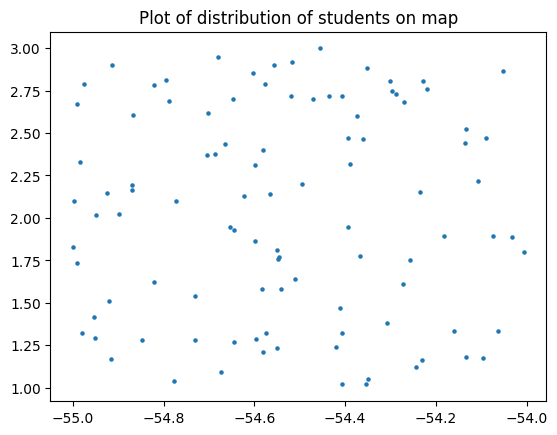

In [ ]:
P = student_graph(100)

loc_attr = nx.get_node_attributes(P, 'pos')
lat = [loc_attr[idx][0] for idx in range(len(loc_attr))]
log = [loc_attr[idx][1] for idx in range(len(loc_attr))]
plt.scatter(lat, log, s=5)
plt.title("Plot of distribution of students on map")
plt.show()

I have been trying to cluster the student-student attributes but all my intentions seem to be too complex.

Therefore, I will do some pretty simple tests to get an indicative result and then iterate from there into something that can reliably handle real data and uncertain inputs.

This first approach is to vectorise student attributes into some space, and cluster those vectors which are similar to each other.

Then, from within these groups, I could add an edge based logic (rather than using KNN) to have a graph of similarity between students.

One note: the way in which the vectorisation of nodes works (within a function) should have some returned object that can be general to unpack for the edge logic function.

More clearly:
```
def cluster_logic(graph):
    return nested_list # the nested lists being the identifier of nodes (e.g. [1,5,66,199])

def edge_weight(cluster_list):
    return edge_weight_list # [[node, comp_node, weight], ...]

# update graph structure by adding the edges
```

In [4]:
def vectorise_topics(topic_vector, topic_list):
    vec = np.zeros(len(topic_list))
    for topic, weight in topic_vector:
        vec[topic_list.index(topic)] = weight
    return vec

In [5]:
n = 50
Q = student_graph(n)

def vectored_dict(graph):
    vect_dict = {}
    for i in range(len(graph)):
        v = vectorise_topics(graph.nodes[i]["topics"], topic_list)
        vect_dict.update({i: v})
    return vect_dict # return a dictionary

Now there is a list of attributes in vector form, I will work through a rudimentary way to cluster the points just to see the full stack working.

There is one idea (that is wholly inefficient) but would be cool to work on.

## Clustering Approaches
### Force-based
I had an idea for a force-based approach to clustering where each vector point is analogous to a point mass experiencing mass, and the points would 'move' closer to similar  such points in this space.

$$F_{attr} \propto \frac{1}{SSE \times S_c}$$

$SSE$ is the squared sum of error between the vector points of two comparing students. $S_c$ is the size of the cluster that the given node is already a part of; how this is defined will probably be the sphere (or equivalent shape in higher dimensions, hypersphere?) of a given radius, $r$.

However, this seemed complicated and I just want a simple model working in this lifetime.

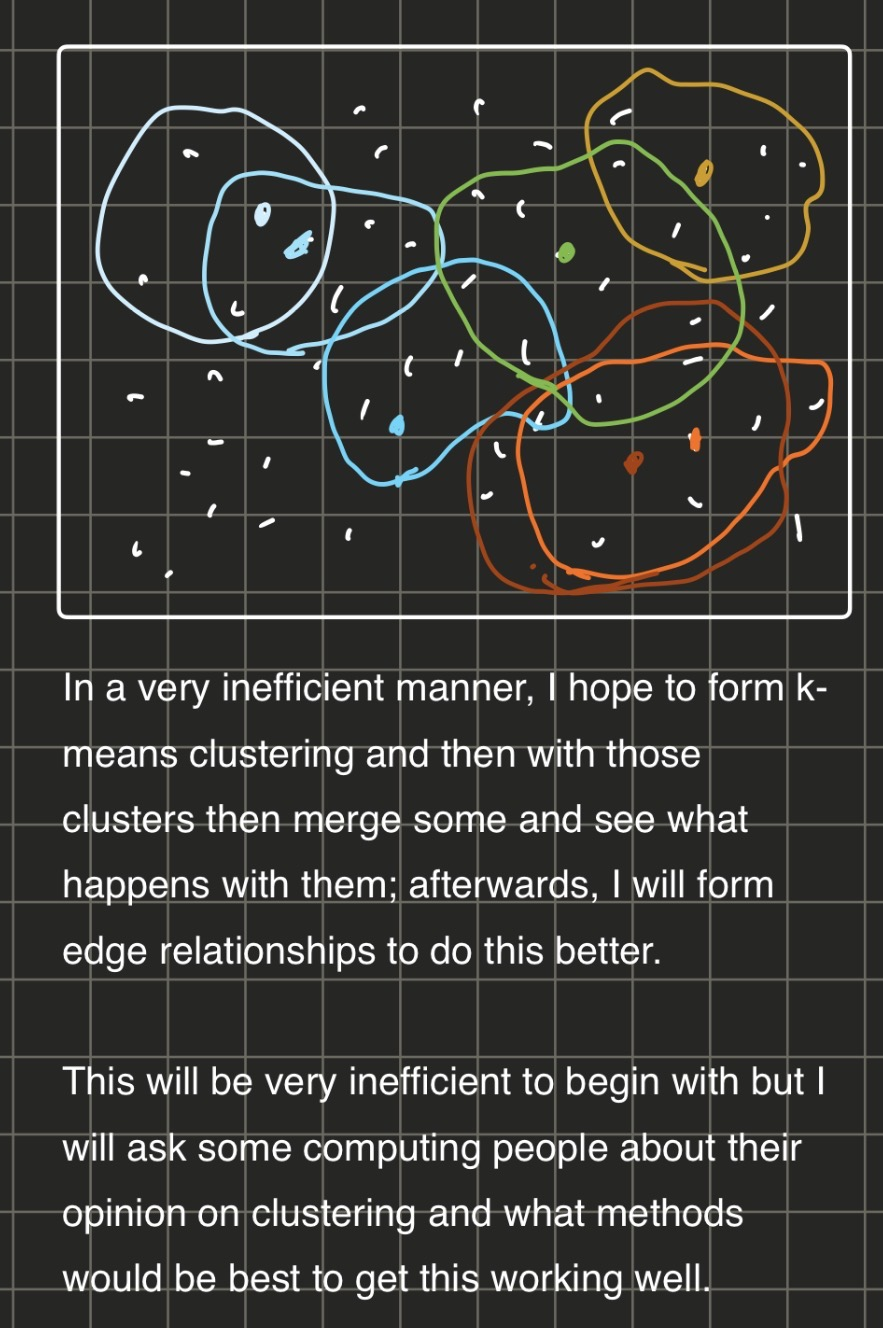

The above image is my attempt currently, which should take about 3 hours (at max).

In [6]:
def sum_square_error(student_id, vect_dict, n):
    # remove student_id from vec_list
    sse = {}
    input_vector = vect_dict[student_id]
    for id, values in vect_dict.items():
        if id != student_id:
            v = np.linalg.norm(input_vector - vect_dict[id])
            #print(v)
            sse.update({id: v})
    sorted_sse = dict(sorted(sse.items(), key=lambda x:x[1]))
    n_sse = (dict(list(sorted_sse.items())[:n]))
    return n_sse

The above algorithm has formed a cluster for a given student and size of n; it was tested below and the outputs are nice. I will run this inefficient (O(n^2)) algorithm to try and form connections.

In [ ]:
u = student_graph(50)

In [ ]:
print(u.nodes()[9])

{'pos': (-54.660866911203115, 1.7306612679540205), 'topics': [('piano', 10), ('physics', 10), ('product design', 3), ('tutoring', 4)], 'budget': 1}


In [ ]:
vect_dict = vectored_dict(u)
n_sse_3 = sum_square_error(5, vect_dict, 8)
print(n_sse_3)

{45: np.float64(10.677078252031311), 47: np.float64(11.704699910719626), 36: np.float64(12.68857754044952), 11: np.float64(13.038404810405298), 8: np.float64(14.7648230602334), 24: np.float64(14.933184523068078), 35: np.float64(15.033296378372908), 38: np.float64(15.394804318340652)}


One thing with running this algorithm across the netwrok is that there will be a lot of overlap between these n-sized clusters.

I will think of ways of dealing with this, then create the edge logic and see how the clustered groups (differentiated by colour but not completely isolated) are.

One test I could do would be measuring the conductance and modularity of communities as n varies (and plot that) just as something more computational to do to see where the smallest good n value would be when using much larger runs of this.

After this, I will copy (approximately) the code for matching students to clubs and I can compare the average edge weights dependent on the formed clusters - which is the entirety of the plan.

### Applying fuzzy k-means clustering

Set $k$ clusters and assign a random membership value of each node to each of the clusters (following some distribution, but start with normal).

Then within each cluster, find the centroid (the central node in a cluster) and compute the average distances between that centroid and every other point.

*After every $q$ updates,  hide set membership of a point as 0 if it is less than a given threshold value of $\sigma$*.*

Repeat these steps until clusters converge.

*I don't know whether this should actually be applied, but something to test out.

For my implementation, I will be coping the page from  `geeksforgeeks.org` as I would like to get something finished today; improvements to this code will be personal implementation within context.

In [7]:
pip install scikit-fuzzy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 33.8 MB/s eta 0:00:00


In [8]:
import skfuzzy as fuzz

An earlier test of code that was written, a test for the upcoming function.

```
node_ids = list(vect_dict.keys())
X = np.array([vect_dict[i] for i in node_ids])
data = X.T

c = 3
cntr, u, u0, d, jm, p, fpc = fuzz.cluster.cmeans(
    data, c=c, m=1.5, error=0.00005, maxiter=50000
)
#labels = np.argmax(u, axis=0)

print((u[0]))
```

The above shows the relative membership of each node in the first cluster.

I can now write the edge logic but, rather than having a complete graph ($K_n$), I would like to set edge weights of values under a certain threshold as zero to make the clusters more granular.

In order to see a lot of change, I will set that threshold to be 0.5 but some changes will occur as well so that it outputs well and the edge logic is nice and clean.

In [10]:
def edge_logic(vect_dict, n_clusters, m=2, threshold=0.5):
    node_ids = list(vect_dict.keys())
    X = np.array([vect_dict[i] for i in node_ids])
    data = X.T
    cntr, u, u0, d, jm, p, fpc = fuzz.cluster.cmeans(
    data, c=n_clusters, m=m, error=0.00005, maxiter=5000
    )
    cleaned_clusters = np.where(u<threshold,0,u) # if a given value is less than 0.5, set it as 0
    return cleaned_clusters # list of cleaned clusters

Now, edge logic where edges are created for this network to form the student-student layer of this graph, which is unweighted.

In [ ]:
test = student_graph(35)

In [ ]:
print((dict(test.nodes[4]['topics']))['maths'])

8


I also needed to add weights between chosen nodes; it was written on handwritten notes but will have to copy up later.

In [11]:
def weight_function(G,i,j, alpha=0.3, beta=0.3, gamma=0.3, phi=0.1):
    # topics
    num_topics_i = len(G.nodes()[i]['topics'])
    num_topics_j = len(G.nodes()[j]['topics'])
    shared_topics_num = 0
    shared_topics = []
    for idxi in range(num_topics_i):
        for idxj in range(num_topics_j):
            if G.nodes()[i]['topics'][idxi][0] == G.nodes()[j]['topics'][idxj][0]:
                shared_topics_num += 1
                shared_topics.append(G.nodes()[i]['topics'][idxi][0])
    ## genuinely, this above algo might be the least efficient of inefficient things i've been doing but I cannot think of anything better
    prop_shared_topics = shared_topics_num / num_topics_i

    # diff between interests
    interest_sum = 0
    for topic in shared_topics:
        interest_i = (dict(G.nodes[i]['topics'])[topic])
        interest_j = (dict(G.nodes[j]['topics'])[topic])
        interest_sum += np.abs(interest_j - interest_i)
    if shared_topics_num == 0:
        prop_shared_interests = 0
    else:
        prop_shared_interests = interest_sum / shared_topics_num

    # budget difference
    budget_similarity = np.abs(G.nodes()[i]['budget'] - G.nodes()[j]['budget'])

    # location similarity
    pos_i = np.array(G.nodes()[i]['pos'])
    pos_j = np.array(G.nodes()[j]['pos'])
    location_similarity = np.linalg.norm(pos_j - pos_i)

    weight = alpha * prop_shared_topics + beta * prop_shared_interests + gamma * budget_similarity + phi * location_similarity
    return weight

In [12]:
def edge_creation(G, clusters, threshold=0.5):
    # create new copy of G so that changes persist?
    G = G.copy()
    G.remove_edges_from(list(G.edges()))
    n_nodes = len(G.nodes())
    for cluster in clusters:
        for i in range(n_nodes):
            for j in range(n_nodes):
                if i != j and not G.has_edge(i,j) and not cluster[j] == 0 and not cluster[i] == 0:
                    weight = weight_function(G,i,j)
                    if weight >= threshold:
                        G.add_edge(i, j, weight=weight)
    return G

In [13]:
graph = student_graph(100)

In [14]:
threshold=0.1
vect_dict = vectored_dict(graph)
clusters = edge_logic(vect_dict, 10, threshold=threshold)
graph_bar = edge_creation(graph, clusters, threshold=threshold)
#print(nx.get_edge_attributes(graph_bar, 'weight'))
print(graph_bar)

Graph with 100 nodes and 2873 edges


At each time step there is still a complete graph even though I have a threshold. I will try to debug this so that the clusters actually have something cool to work with (rather than pruning edges with another function).

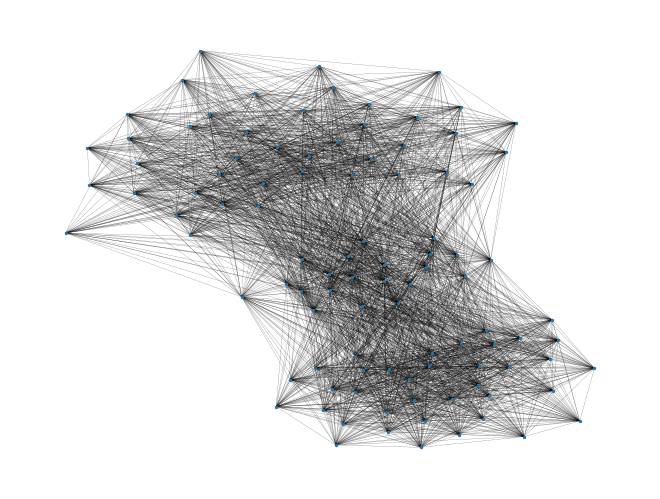

In [15]:
pos = nx.spring_layout(graph_bar, weight='weight')
nx.draw(graph_bar, pos=pos, node_size=2, width=.1)

## Clubs
Make clubs as a similar vector structure and the bipartite graph will source the IDs and attributes from the student-student graph.

This work is the same as was done before so should not take too much time.

## Analysis
For each set of clusters (in the intial graph), try to:
- qualitatively say why a given cluster is clustered together (e.g. low interest in robotics but quite enjoy reading, high range of abilities in other subjects but highly involved in something outside of robotics and reading).

- compare average weights and distribution of weights (and plot these distributions for this synthetic data)

- {data is random so I am not expecting meaningful distributions, however, this can be part of the ask to see the application of this (when doing surveys)}

## Post e-mail sending
*I will send emails once the above is completed. After sending them, the below will occur. These points will be mentioned in the emails:*

- see mechanisms to adding new clubs (on a map dynamically) or suggesting where a new club could be (with suggested attributes that could minimise the average weight of the cluster).
- making an interactive frontend for this (maybe with folio, but I could collaborate with someone else who has more experience in frontedn)
- add more vector attributes that focuses on the cost and other points that are considered for the planning of these clubs and where to put charities.
- ask for data of this in an existing way and {somehow} try to implement this data with my model (and understand the limitations of doing so).

In [37]:
# function that will produce a copy of nodes in earlier graph
def student_extraction(graph):
    copied_graph = graph.copy()
    # remove all student-student edges from this
    copied_graph.remove_edges_from(list(copied_graph.edges()))
    # be clearer which nodes are students (so that this could be done with the clubs)
    student_mapping = {val:f'S{val}' for val in copied_graph.nodes()}
    graph = nx.relabel_nodes(copied_graph, student_mapping)
    nx.set_node_attributes(graph, "student", name="node_type")
    return graph

I will create the clubs and their attributes.

In [20]:
def staff_function(max_cap, ratio=1/5):
    # one staff member for every 5 students (as a basic rule)
    staff_number = round(max_cap * ratio)
    return staff_number

def club_graph(num, graph_copy):
    for club in range(num):
        pos = random_location() #follows same distribution as for students
        topic = random.choice(topic_list)
        cost_to_student = random.choice([0,0,0,0,0,0,0,0,5,5,5,5,5,10,15,30,50])# I want it to follow this distribution but idk what function that could be
        max_capacity = random.choice(np.arange(5,50,5).tolist())
        staff_numbers = staff_function(max_capacity)
        # cost_to_council = f(max_capacity, staff_numbers, pos)
        graph_copy.add_node(f'C{club}', node_type="club", pos=pos, topic=topic, cost_to_student=cost_to_student, max_capacity=max_capacity, staff_numbers = staff_numbers)
    return graph_copy

Now I will do the logic of connecting the students to clubs in a similar vain to my first attempt; this is the edge logic

In [49]:
# edge weighting function
def edge_weighting_function(graph, student, club):
    # write how I would like this to be weighted, as a point to be developed later
    a, b, c, d = 0.25, 0.25, 0, 0 # weighting of variables
    # the maximum distance points can be in my location distribution is sqrt(3)
    dist_cost = np.linalg.norm(np.array(graph.nodes[student]['pos']) - np.array(graph.nodes[club]['pos'])) / np.sqrt(3)

    cost_to_student = graph.nodes[club]['cost_to_student']
    budget_lim = graph.nodes[student]['budget']

    student_cost = cost_to_student/budget_lim if budget_lim > cost_to_student else 0 if budget_lim == cost_to_student == 0 else 1

    # I will add the other two points later
    interest_cost = 0 # to update later
    government_cost = 0

    weight = a * dist_cost + b * student_cost + c * interest_cost + d * government_cost
    return weight # scalar value

#student-club graph
def student_club_edges(G):
    # for each student whose node name is of class S
    club_nodes = [
    node for node, data in G.nodes(data=True) if data.get("node_type") == "club"
]
    student_nodes = [
    node for node, data in G.nodes(data=True) if data.get("node_type") == "student"
]

    for student in student_nodes:
        s_topics = set(G.nodes[student]["topics"])
        for club in club_nodes:
            shared = s_topics and set(G.nodes[club]["topic"])
            if shared:
                G.add_edge(student, club, weight=edge_weighting_function(G, student, club))

    for club in club_nodes:
        cap = G.nodes[club]["max_capacity"]
        # since the data is in the form {student, club, weight}, e[2] just means the data is sorted by the edge weight.
        # will work more on implementing lambda/inline functions
        edges = sorted(G.edges(club, data="weight"), key=lambda e: e[2], reverse=True)
        G.remove_edges_from([(u, v) for u, v, _ in edges[cap:]])
    return G

Now I will run everything

In [30]:
graph = student_graph(100)
threshold=0.1
vect_dict = vectored_dict(graph)
clusters = edge_logic(vect_dict, 10, threshold=threshold)
graph_bar = edge_creation(graph, clusters, threshold=threshold)
#print(nx.get_edge_attributes(graph_bar, 'weight'))
print(graph_bar)

Graph with 100 nodes and 3645 edges


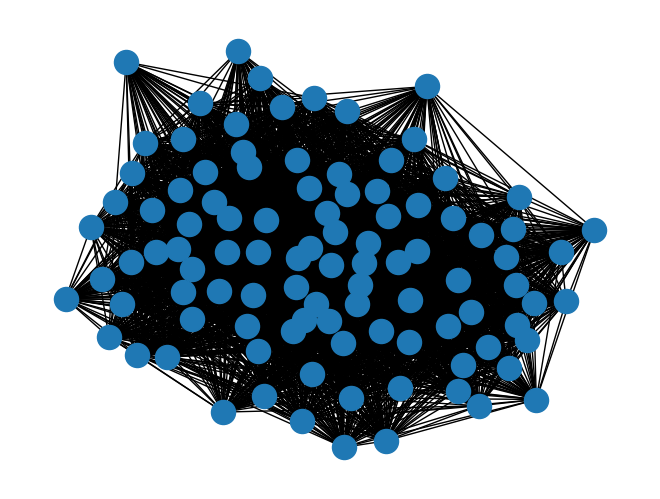

In [34]:
nx.draw(graph_bar)

In [50]:
copied_graph = student_extraction(graph_bar)
new_graph = club_graph(20, copied_graph)
#print(new_graph.nodes['S4'])
student_club_graph = student_club_edges(new_graph)
print(student_club_graph)

Graph with 120 nodes and 515 edges


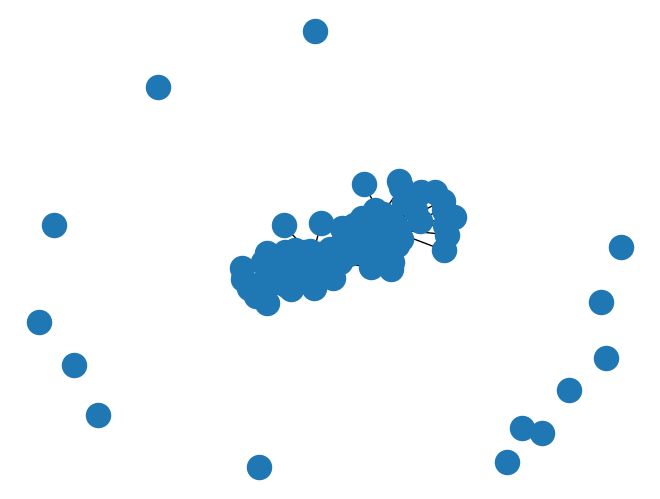

In [51]:
nx.draw(student_club_graph)